# Step 6 - Downstream Analytics
This notebook shows how reconstruction quality affects route distance, emissions, and cross-track deviation.
It compares the GRU output against the great-circle baseline on practical metrics.


In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name in ('notebooks','src') else Path.cwd()
SRC_ROOT     = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

STEP6_ROOT = PROJECT_ROOT / 'artifacts' / 'step6_analytics'

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project root: {PROJECT_ROOT}')
print(f'Step 6 root:  {STEP6_ROOT}')
print(f'Exists: {STEP6_ROOT.exists()}')

Project root: c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version
Step 6 root:  c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step6_analytics
Exists: True


## Build Step 6 Outputs
Run this cell only when you need to regenerate the analytics artifacts.
For review, keep the build path off and load the saved outputs below.


In [2]:
RUN_STEP6 = False   # Set True to rebuild

if RUN_STEP6:
    from aero_fusion.step6_analytics import run_step6_analytics
    summary = run_step6_analytics(verbose=True)
else:
    print('RUN_STEP6=False — loading saved outputs')

RUN_STEP6=False — loading saved outputs


## Load Results
This section reads the saved Step 6 catalogs and example tracks.
It is the normal starting point for analysis and presentation.


In [3]:
summary_path = STEP6_ROOT / 'catalog' / 'analytics_summary.json'
if not summary_path.exists():
    raise FileNotFoundError(f'Run step 6 first: {summary_path}')

summary = json.loads(summary_path.read_text())
analytics = pd.read_parquet(STEP6_ROOT / 'catalog' / 'flight_analytics.parquet')

print(json.dumps(summary, indent=2))
print(f'\nLoaded analytics for {len(analytics)} flights')

{
  "flights_analyzed": 240,
  "flights_skipped": 0,
  "route_distance": {
    "gru_mean_km": 5732.321401988238,
    "baseline_mean_km": 5712.0963360884025,
    "mean_diff_km": 20.22506589983669,
    "gru_longer_pct": 100.0
  },
  "emissions_proxy": {
    "fuel_burn_coeff_kg_co2_per_km": 90.0,
    "gru_mean_co2_kg": 515908.9261789415,
    "baseline_mean_co2_kg": 514088.6702479561,
    "mean_co2_diff_kg": 1820.255930985305
  },
  "cross_track_deviation": {
    "gru_mean_xt_km": 105.87952909831999,
    "gru_max_xt_km": 147.24166039379799
  }
}

Loaded analytics for 240 flights


## Route Distance Comparison
These results show how each reconstruction changes total route length.
Distance is the simplest downstream consequence of gap-filling quality.


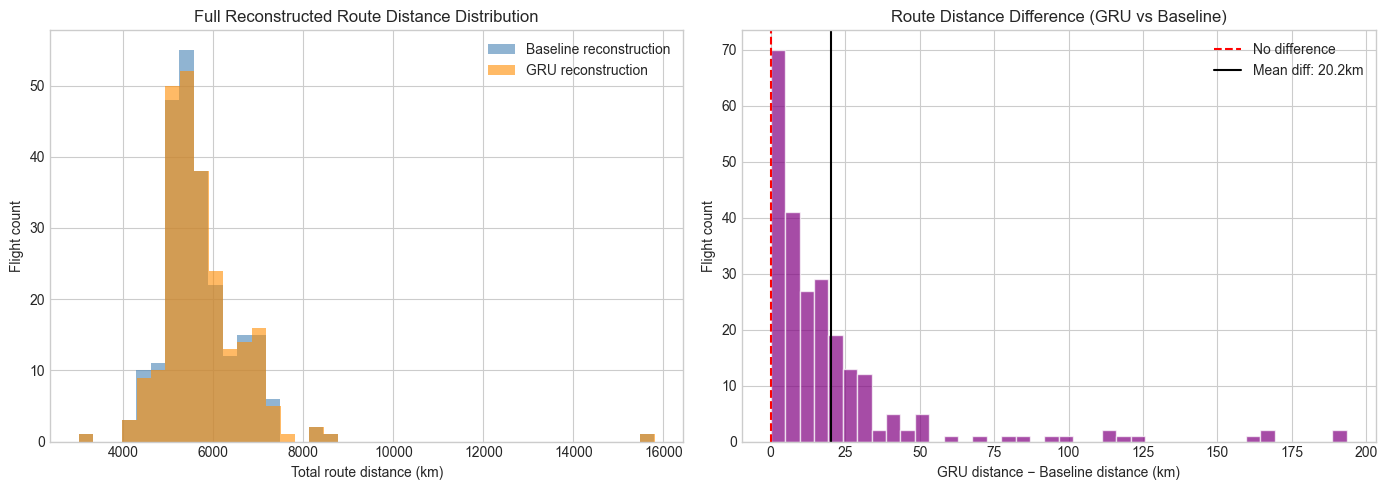

GRU mean route distance    : 5732.3 km
Baseline mean route distance: 5712.1 km
Mean difference            : 20.2 km
GRU path longer than baseline: 240/240 flights (100.0%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total route distance
axes[0].hist(analytics['baseline_total_dist_km'].dropna()/1, bins=40,
             alpha=0.6, label='Baseline reconstruction', color='steelblue')
axes[0].hist(analytics['gru_total_dist_km'].dropna()/1,      bins=40,
             alpha=0.6, label='GRU reconstruction',      color='darkorange')
axes[0].set_xlabel('Total route distance (km)')
axes[0].set_ylabel('Flight count')
axes[0].set_title('Full Reconstructed Route Distance Distribution')
axes[0].legend()

# Distance difference scatter
diff = analytics['dist_diff_km'].dropna()
axes[1].hist(diff, bins=40, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(0,              color='red',  linestyle='--', label='No difference')
axes[1].axvline(diff.mean(),    color='black', linestyle='-', label=f'Mean diff: {diff.mean():.1f}km')
axes[1].set_xlabel('GRU distance − Baseline distance (km)')
axes[1].set_ylabel('Flight count')
axes[1].set_title('Route Distance Difference (GRU vs Baseline)')
axes[1].legend()

plt.tight_layout()
plt.savefig(STEP6_ROOT / 'route_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"GRU mean route distance    : {analytics['gru_total_dist_km'].mean():.1f} km")
print(f"Baseline mean route distance: {analytics['baseline_total_dist_km'].mean():.1f} km")
print(f"Mean difference            : {diff.mean():.1f} km")
print(f"GRU path longer than baseline: {(diff>0).sum()}/{len(diff)} flights ({(diff>0).mean()*100:.1f}%)")

## Emissions Proxy
This section converts route differences into a simple emissions proxy.
It gives the reconstruction error a more operational interpretation.


C:\Users\ANTOINE\AppData\Local\Temp\ipykernel_19140\2928412308.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ANTOINE\AppData\Local\Temp\ipykernel_19140\2928412308.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(STEP6_ROOT / 'emissions_proxy.png', dpi=150, bbox_inches='tight')
c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


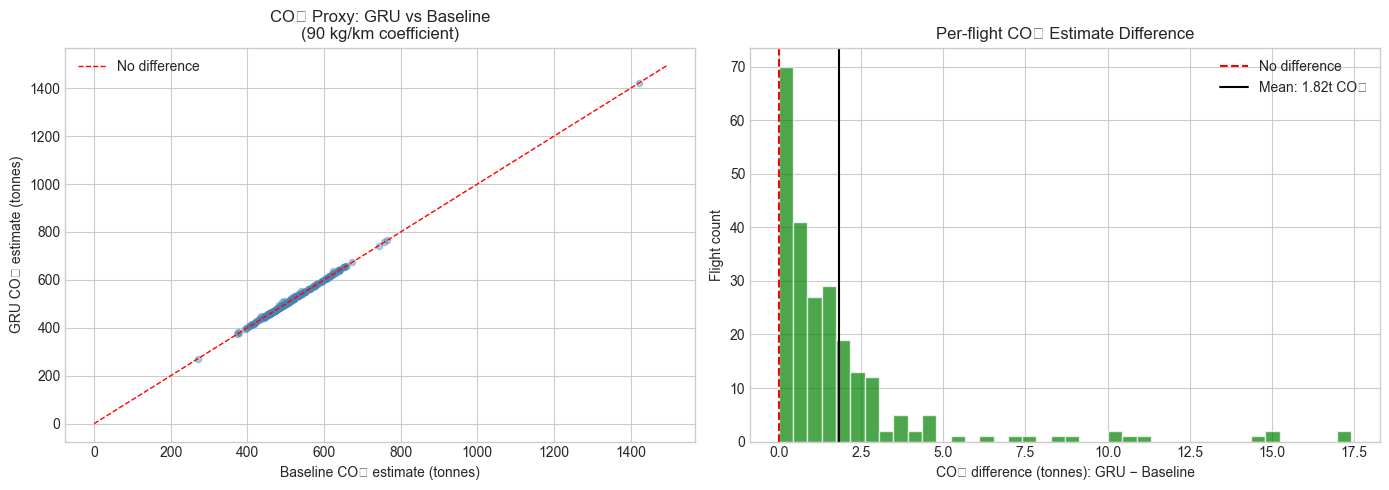

Mean CO₂ per flight — GRU     : 515.91 tonnes
Mean CO₂ per flight — Baseline: 514.09 tonnes
Mean difference               : 1.82 tonnes CO₂

Practical significance: baseline overestimates CO₂ by ~1.8t
if the GRU reconstruction is assumed to be the better path estimate.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO2 comparison
axes[0].scatter(
    analytics['baseline_co2_kg']/1000,
    analytics['gru_co2_kg']/1000,
    alpha=0.4, s=20, color='steelblue'
)
lim = max(analytics['baseline_co2_kg'].max(), analytics['gru_co2_kg'].max()) / 1000 * 1.05
axes[0].plot([0,lim],[0,lim],'r--',lw=1, label='No difference')
axes[0].set_xlabel('Baseline CO₂ estimate (tonnes)')
axes[0].set_ylabel('GRU CO₂ estimate (tonnes)')
axes[0].set_title('CO₂ Proxy: GRU vs Baseline\n(90 kg/km coefficient)')
axes[0].legend()

# CO2 difference distribution
co2_diff = analytics['co2_diff_kg'].dropna() / 1000  # tonnes
axes[1].hist(co2_diff, bins=40, color='green', alpha=0.7, edgecolor='white')
axes[1].axvline(0,              color='red',   linestyle='--', label='No difference')
axes[1].axvline(co2_diff.mean(), color='black', linestyle='-',
                label=f'Mean: {co2_diff.mean():.2f}t CO₂')
axes[1].set_xlabel('CO₂ difference (tonnes): GRU − Baseline')
axes[1].set_ylabel('Flight count')
axes[1].set_title('Per-flight CO₂ Estimate Difference')
axes[1].legend()

plt.tight_layout()
plt.savefig(STEP6_ROOT / 'emissions_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean CO₂ per flight — GRU     : {analytics['gru_co2_kg'].mean()/1000:.2f} tonnes")
print(f"Mean CO₂ per flight — Baseline: {analytics['baseline_co2_kg'].mean()/1000:.2f} tonnes")
print(f"Mean difference               : {co2_diff.mean():.2f} tonnes CO₂")
print(f"\nPractical significance: baseline overestimates CO₂ by ~{abs(co2_diff.mean()):.1f}t")
print(f"if the GRU reconstruction is assumed to be the better path estimate.")

## Cross-Track Deviation
These plots measure how far each method drifts from the reference path geometry.
They highlight shape errors that route-length summaries can hide.


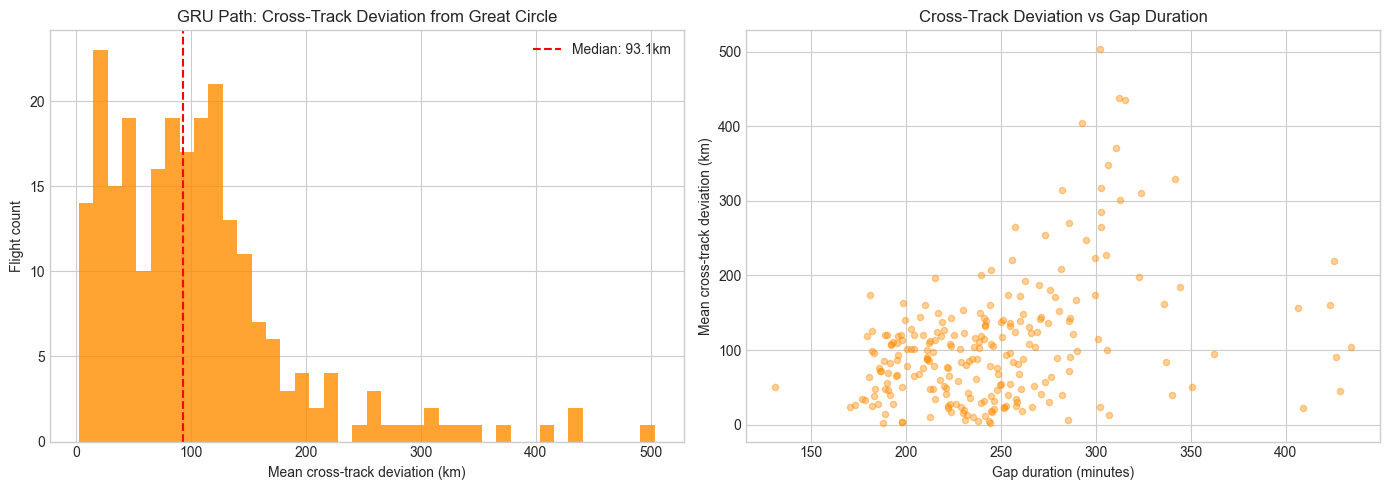

Mean cross-track deviation : 105.9 km
Median cross-track deviation: 93.1 km

Interpretation: the GRU path deviates this far from the straight great-circle arc
on average — confirming aircraft follow NAT tracks, not straight lines.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(analytics['gru_mean_xt_km'].dropna(), bins=40, color='darkorange', alpha=0.8)
axes[0].set_xlabel('Mean cross-track deviation (km)')
axes[0].set_ylabel('Flight count')
axes[0].set_title('GRU Path: Cross-Track Deviation from Great Circle')
med_xt = analytics['gru_mean_xt_km'].median()
axes[0].axvline(med_xt, color='red', linestyle='--', label=f'Median: {med_xt:.1f}km')
axes[0].legend()

# Cross-track vs gap duration
axes[1].scatter(
    analytics['gap_duration_minutes'],
    analytics['gru_mean_xt_km'],
    alpha=0.4, s=20, color='darkorange'
)
axes[1].set_xlabel('Gap duration (minutes)')
axes[1].set_ylabel('Mean cross-track deviation (km)')
axes[1].set_title('Cross-Track Deviation vs Gap Duration')

plt.tight_layout()
plt.savefig(STEP6_ROOT / 'cross_track.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean cross-track deviation : {analytics['gru_mean_xt_km'].mean():.1f} km")
print(f"Median cross-track deviation: {analytics['gru_mean_xt_km'].median():.1f} km")
print("")
print("Interpretation: the GRU path deviates this far from the straight great-circle arc")
print("on average — confirming aircraft follow NAT tracks, not straight lines.")

## Full Reconstructed Trajectories
These examples show complete stitched flights for the compared methods.
Use them to connect the metrics back to the underlying track geometry.


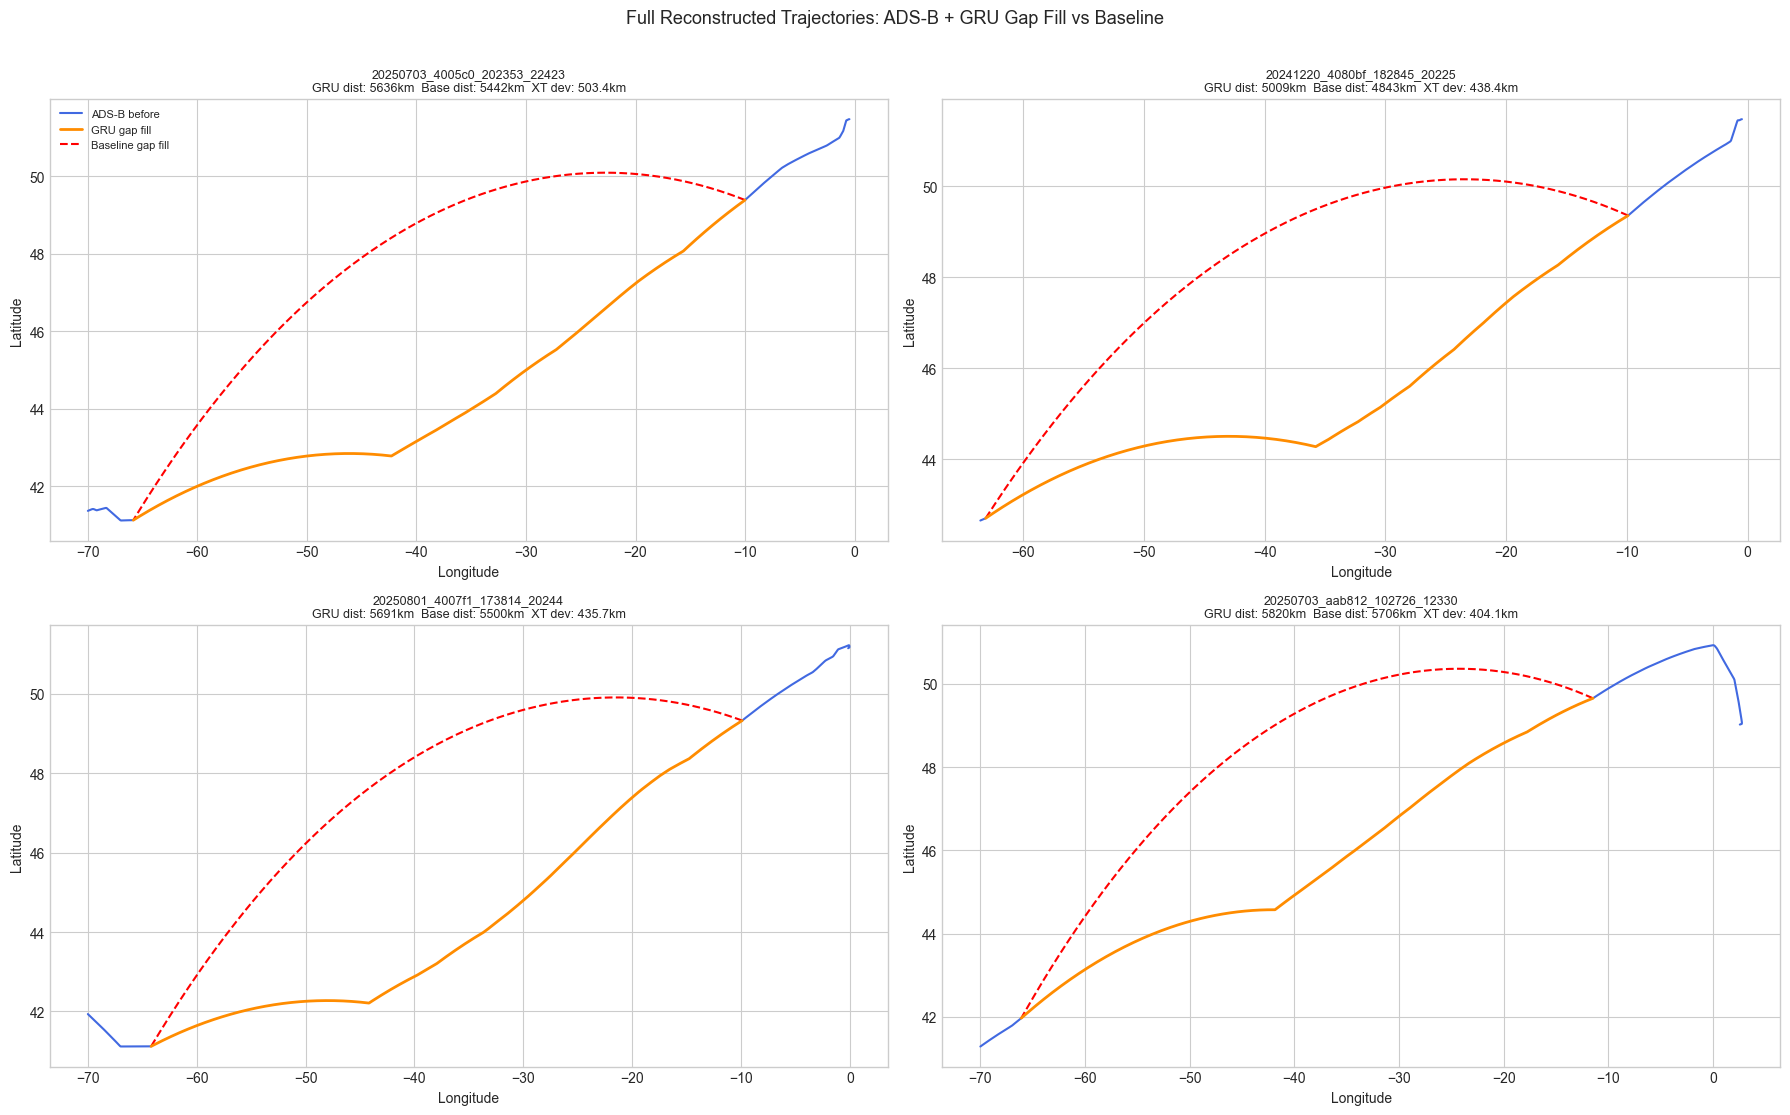

In [7]:
# Pick 4 flights with the largest GRU cross-track deviation (most interesting to show)
top4 = analytics.dropna(subset=['gru_mean_xt_km']).nlargest(4,'gru_mean_xt_km')['segment_id'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

for ax, seg_id in zip(axes, top4):
    rec_dir = STEP6_ROOT / 'reconstructions' / seg_id
    gru_path  = rec_dir / 'full_track_gru.parquet'
    base_path = rec_dir / 'full_track_baseline.parquet'

    if not gru_path.exists():
        ax.set_title(f'{seg_id}\n(file missing)')
        continue

    gru_track  = pd.read_parquet(gru_path)
    base_track = pd.read_parquet(base_path)

    # Plot by source
    for source, color, label, lw, zorder in [
        ('adsb_before', 'royalblue',  'ADS-B before', 1.5, 2),
        ('gru_interp',  'darkorange', 'GRU gap fill', 2.0, 3),
        ('adsb_after',  'royalblue',  'ADS-B after',  1.5, 2),
    ]:
        seg = gru_track[gru_track['source'] == source]
        if not seg.empty:
            ax.plot(seg['longitude'], seg['latitude'],
                    '-', color=color, lw=lw, zorder=zorder,
                    label=label if source != 'adsb_after' else '_nolegend_')

    # Baseline gap fill
    bl_gap = base_track[base_track['source'] == 'gc_interp']
    if not bl_gap.empty:
        ax.plot(bl_gap['longitude'], bl_gap['latitude'],
                'r--', lw=1.5, zorder=1, label='Baseline gap fill')

    row = analytics[analytics['segment_id']==seg_id].iloc[0]
    ax.set_title(
        f'{seg_id[:28]}\n'
        f'GRU dist: {row["gru_total_dist_km"]:.0f}km  '
        f'Base dist: {row["baseline_total_dist_km"]:.0f}km  '
        f'XT dev: {row["gru_mean_xt_km"]:.1f}km',
        fontsize=9
    )
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if ax is axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Full Reconstructed Trajectories: ADS-B + GRU Gap Fill vs Baseline',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(STEP6_ROOT / 'full_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table
This table consolidates the main downstream comparisons in one place.
Keep the notebook on saved outputs unless you intentionally rebuild Step 6.


In [8]:
print('='*65)
print('STEP 6 — DOWNSTREAM ANALYTICS SUMMARY')
print('='*65)
print(f"Flights analyzed: {len(analytics)}")
print()
print(f"  {'Metric':<40} {'GRU':>12} {'Baseline':>12}")
print(f"  {'-'*65}")
print(f"  {'Mean route distance (km)':<40} "
      f"{analytics['gru_total_dist_km'].mean():>12.1f} "
      f"{analytics['baseline_total_dist_km'].mean():>12.1f}")
print(f"  {'Mean CO₂ estimate (tonnes)':<40} "
      f"{analytics['gru_co2_kg'].mean()/1000:>12.2f} "
      f"{analytics['baseline_co2_kg'].mean()/1000:>12.2f}")
print(f"  {'Mean cross-track deviation (km)':<40} "
      f"{analytics['gru_mean_xt_km'].mean():>12.1f} "
      f"{'N/A (is baseline)':>12}")
print()
diff_km = analytics['dist_diff_km'].mean()
print(f"  Route distance difference (GRU - Baseline): {diff_km:+.1f} km per flight")
print(f"  CO₂ difference: {analytics['co2_diff_kg'].mean()/1000:+.2f} tonnes per flight")
print()
print("  Interpretation:")
if diff_km > 0:
    print(f"  GRU paths are on average {diff_km:.1f}km longer than baseline,")
    print("  reflecting that real NAT tracks curve away from the great circle.")
else:
    print(f"  GRU paths are on average {abs(diff_km):.1f}km shorter than baseline,")
    print("  suggesting the baseline overshoots the real route in some cases.")
print('='*65)

for f in ['route_distance.png','emissions_proxy.png','cross_track.png','full_trajectories.png']:
    p = STEP6_ROOT / f
    print(f"  {'OK' if p.exists() else 'MISSING'}: {f}")

STEP 6 — DOWNSTREAM ANALYTICS SUMMARY
Flights analyzed: 240

  Metric                                            GRU     Baseline
  -----------------------------------------------------------------
  Mean route distance (km)                       5732.3       5712.1
  Mean CO₂ estimate (tonnes)                     515.91       514.09
  Mean cross-track deviation (km)                 105.9 N/A (is baseline)

  Route distance difference (GRU - Baseline): +20.2 km per flight
  CO₂ difference: +1.82 tonnes per flight

  Interpretation:
  GRU paths are on average 20.2km longer than baseline,
  reflecting that real NAT tracks curve away from the great circle.
  OK: route_distance.png
  OK: emissions_proxy.png
  OK: cross_track.png
  OK: full_trajectories.png
